# Alan Brosnan Final Part 2

Note: This is an individual project. Name: Alan Brosnan EID: anb5226

In [1]:
#solve a stiff ordinary differential equation (ODE) that arises in real-world applications
# implement Euler's Backward (Implicit Euler) method using Newton-Raphson iteration to solve the resulting nonlinear equation at each time step. 


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Parameters:
conv_h = 1500
dt = 0.01
t_start = 0
t_end = 20
T_initial = 1000
# ambient forcing
def T_inf(t):
    return 300 + 10*np.sin(0.01*t)
# ODE function (kept but not required in computation)
def dTdt(T, t):
    return -conv_h * (T - T_inf(t))

# Section 1: Introduction & System Selection

Description of Chosen Stiff System: 
The chosen stiff system is the Cooling with Forced Convection stiff First Order Differential Equation. The forced convection ODE models Newton’s law of cooling applied to a system in which cool fluid (or air) is being moved across a hot surface, such as a turbine blade in a jet engine, by a pump or a fan. The ODE reflects how a solid object changes temperature as it loses heat to the fluid/air that flows over it. In the particular application I chose for the Cooling with Forced Convection ODE, I have applied the ODE to model the temperature loss in an F-16 fighter jet’s turbine blades as air runs through the singular General Electric F110 turbofan.  


Governing ODE:
Option C: Cooling with Forced Convection: dT/dt= -h(T-T(infinity(t))

My application of governing ODE: 
dTb/dt = -1500Tb +1,125,000 + 150,000*sin(0.01t) #FIX THIS NOW

Physical Meaning of Variables and Parameters:

Convection Coefficient
The convection coefficient is the intensity of the cooling air along the jet's flight/maneuver. Having a high h such as 1500, insinuates that the air moves at intense speeds, which causes the blade to shift its temperature and cool down as the air passes over. 

Film Temperature
This is the local climate of the air around the blade. It can be thought of as the air that lies locally over the blade. As the jet climbs or changes maneuvers, it is subject to change because the air provided by the compressor will change in temperature. The film temperature is divided into the Steady State Base Line (Tbase), Amplitude (Delta T), and frequency (Time Scaling). The Steady State Base Line (SSBL) is the equilibrium temperature the blade reaches during a steady, constant speed flight. The Amplitude or operational intensity represents the swings in temperature caused by different pilot maneuvers. The frequency is how fast the temperature around the jet changes compared to the engine. 

Rate of Temperature Change
This is the responsiveness of the thermal activity in the blade. If the rate of temperature change is high, that means the blade experiences thermal shock as it experiences a profound change in temperature. Having a high rate of temperature change could cause the turbine blade to crack or deform. 

Blade Temperature
This is representative of the temperature of the turbine blade. It is the result of the combination of heated exhaust gases and the cooling air flow.

Time
Time is representative of the time that is taken in the flight or in the maneuver that is causing the temperature change. 


Why is the System Important in Practice?

The cooling with forced convection ODE is important in practice because it is representative of heat transfer rates, which are important in mechanical application sand vehicular applications. The equation is important to maximize or minimize heat transfer to ensure operation in safe environments. In my particular application, using the forced convection ODE to model heat transfer between airflow and turbine blades is important because without proper modelling, the temperature of the blades could reach critical temperatures that cause the blade to melt during flight. 


# Section 2: Demonstration of Stiffness

<ipython-input-4-baa158ccf66a>:9: RuntimeWarning: overflow encountered in double_scalars
  dT = -conv_h * (T_n - T_inf(t_n))
<ipython-input-4-baa158ccf66a>:10: RuntimeWarning: invalid value encountered in double_scalars
  T_values[i] = T_n + dt * dT


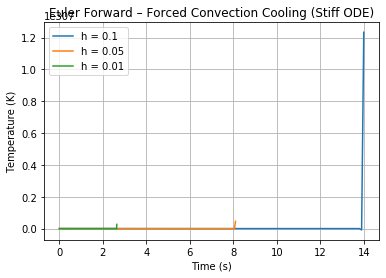

In [4]:
#Attempt to solve with Eulers Forward
def euler_forward(T_initial, t_start, t_end, dt):
    t_values = np.arange(t_start, t_end + dt, dt)
    T_values = np.zeros(len(t_values))
    T_values[0] = T_initial
    for i in range(1, len(t_values)):
        t_n = t_values[i-1]
        T_n = T_values[i-1]
        dT = -conv_h * (T_n - T_inf(t_n))
        T_values[i] = T_n + dt * dT
    return t_values, T_values

#Plotting eulers forward
plt.figure()
dt_steps = [0.1, 0.05, 0.01]
for dt_fe in dt_steps:
    t, T = euler_forward(T_initial, t_start, t_end, dt_fe)
    plt.plot(t, T, label=f"h = {dt_fe}")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Euler Forward – Forced Convection Cooling (Stiff ODE)")
plt.legend()
plt.grid(True)
plt.show()

#Show slash write about the instability

When using Euler's forward method it's easy to see that the graph quickly becomes unstable even with lower h steps such as 0.1,0.05, and 0.01. This means that the equation reaches instability and diverges from reaching a meaningful temperature. This is demonstrated by the spikes shown on the graph, as they all spike upward. When shown on a smaller t axis, both the 0.05 and the 0.01 are shown to spike and fail to reach convergence. Additionally, the instability can be demonstrated by the runtime overflow warnings given when plotting the graph.

In [17]:
#Calculate the stiffness ratio
# time scales
tau_fast = 1 / conv_h
tau_slow = 1 / 0.01 # forcing time scale

# stiffness ratio
R = tau_slow / tau_fast

print("Fast time scale (tau_fast):", tau_fast)
print("Slow time scale (tau_slow):", tau_slow)
print("Stiffness ratio R:", R)

Fast time scale (tau_fast): 0.0006666666666666666
Slow time scale (tau_slow): 100.0
Stiffness ratio R: 150000.0


In [6]:
#Show the impracticality of explicit methods:
dt_stable = 2 / conv_h
print("Estimated Euler Forward stability limit dt:", dt_stable)
      
#Estimate the step size required for Euler's Forward stability     
N_steps_stable = (t_end - t_start) / dt_stable
print("Steps needed for stability:", N_steps_stable)
      
#Calculate how many steps would be needed for the full simulation
for dt_test in [0.1, 0.05, 0.01]:
    print(dt_test, "steps:", (t_end - t_start)/dt_test)

Estimated Euler Forward stability limit dt: 0.0013333333333333333
Steps needed for stability: 15000.0
0.1 steps: 200.0
0.05 steps: 400.0
0.01 steps: 2000.0


Demonstrate computational burden:

It's easy to see the computational burden in using the Euler's forward. It approximates a 15000 steps needed for stability which requires an extremely small h value that will take a lot of time to compute an effective graph. Additionally, in the shown step sizes the number of steps needed for a full simulation reach high numbers while also failing to converge thus showing the inability to provide an effect converging graph while running under cheaper computational cost.

#insert and explain why implicit methods are necessary
Since Euler's forward requires a large number of steps and an extremely small h size, implicit methods are necessary because they remain stable with less step sizes and larger h values.

# Section 3: Mathematical Setup

In [7]:
#write the residual function for specific problem
def residual(T_new, T_old, t_new, dt):
    return (1 + conv_h*dt)*T_new - T_old - conv_h*dt*T_inf(t_new)

In [8]:
#analytically derive g prime
def residual_derivative(dt):
    return 1 + conv_h*dt

In [9]:
#run newton-raphson update formula for your specific problem
# Newton-Raphson iteration to solve for T_new
def solve_T_new(T_old, t_new, dt):
    T = T_old  # initial guess
    for _ in range(10):
        F = (1 + conv_h*dt)*T - T_old - conv_h*dt*T_inf(t_new)
        F_prime = 1 + conv_h*dt
        T_next = T - F / F_prime
        if abs(T_next - T) < 1e-6:
            return T_next
        T = T_next
    return T

The backward euler used to solve for T new is an implicit function which will be useful to solve the stiff ODE as it wont require as many steps or as small of a h step size to converge. Additionally, since my system is linear the derivative is constant which simplies the iterations. 

# Section 4: Implementation

In [10]:
#function defining f(t,y) defiing my ODE- already defined by dTdt
#Derive g prime (yn+1) or use constant value for linear problems- Derived in the backward euler with F_prime

In [11]:
def newton_raphson(F, F_prime, x0, tol=1e-6, max_iter=50):
    x = x0
    for i in range(max_iter):
        x_new = x - F(x)/F_prime(x)
        if abs(x_new - x) < tol:
            return x_new, i+1
        x = x_new
    return x, max_iter

In [12]:
#run newton-raphson update formula for your specific problem
# Newton-Raphson for single step with Backward Euler
# Backward Euler step using Newton-Raphson
def backward_euler_step(T_old, t_new, dt):
    def F(T_new):
        return T_new - T_old - dt * (-conv_h * (T_new - T_inf(t_new)))
    def F_prime(T_new):
        return 1 + conv_h * dt
    T_guess = T_old
    T_next, iters = newton_raphson(F, F_prime, T_guess)#use the newton raphson
    return T_next, iters
# Time stepping using Backward Euler
iters_list = []
t_values = np.arange(t_start, t_end + dt, dt)
T_values = np.zeros(len(t_values))
T_values[0] = T_initial
for i in range(1, len(t_values)):
    T_values[i], iters = backward_euler_step(T_values[i-1], t_values[i], dt)
    iters_list.append(iters)

Newton Raphson is implemented into the backward euler step to solve for the implicit equation. In using this convergence can be met in a small number of steps due to the linearity of the derivative system. 

# Section 5: Results and Analysis

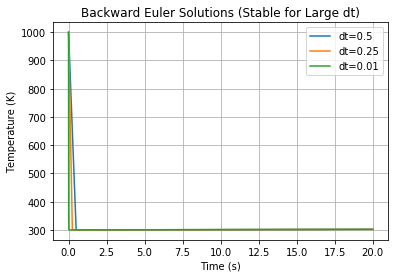

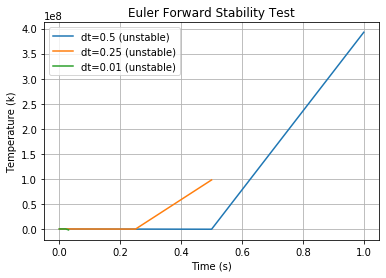

In [13]:
#Solutions for multiple step sizes
#defining the step sizes:
h_steps= [0.5,0.25,0.01]

#Eulers backward stability
plt.figure()
for dt_be in h_steps:
    t_values = np.arange(t_start, t_end + dt_be, dt_be)
    T_values = np.zeros(len(t_values))
    T_values[0] = T_initial
    for i in range(1, len(t_values)):
        T_values[i], _ = backward_euler_step(T_values[i-1],t_values[i],dt_be)
    plt.plot(t_values, T_values, label=f"dt={dt_be}")

plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Backward Euler Solutions (Stable for Large dt)")
plt.legend()
plt.grid()
plt.show()

#Eulers stability test (forward)
plt.figure()
for dt_fe in h_steps:
    t_values = np.arange(t_start, t_end + dt_fe, dt_fe)
    T_values = np.zeros(len(t_values))
    T_values[0] = T_initial
    stable = True
    last_i = 0
    for i in range(1, len(t_values)):
        T_values[i] = T_values[i-1] + dt_fe * (-conv_h * (T_values[i-1] - T_inf(t_values[i-1])))
        last_i = i
        if abs(T_values[i]) > 1e6 or np.isnan(T_values[i]):
            stable = False
            break
    plt.plot(t_values[:last_i+1], T_values[:last_i+1],
             label=f"dt={dt_fe} {'(unstable)' if not stable else ''}")
plt.title("Euler Forward Stability Test")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (k)")
plt.legend()   # now safe
plt.grid()
plt.show()

Backward Euler was tested with different h step sizes (0.5,0.25,0.01). In these test it was found they they were all able converge to stability in which they converged to a stable temperature at 300K. Additionally, the smaller the h step the faster it's able to converge, but it still manages to converge regardless of the larger step size. However, the Euler forward step is unable to reach stability and every h size shows to diverge from a stable temperature. 

<ipython-input-4-baa158ccf66a>:9: RuntimeWarning: overflow encountered in double_scalars
  dT = -conv_h * (T_n - T_inf(t_n))
<ipython-input-4-baa158ccf66a>:10: RuntimeWarning: invalid value encountered in double_scalars
  T_values[i] = T_n + dt * dT


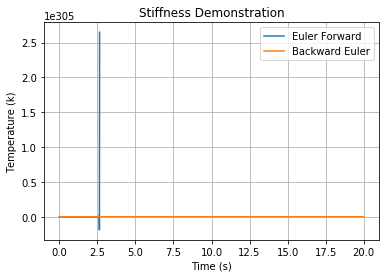

In [14]:
#Comparison plots showing solution behavior
dt_compare = 0.01
#euler plot
t_f, T_f = euler_forward(T_initial, t_start, t_end, dt_compare)
t_b = np.arange(t_start, t_end + dt_compare, dt_compare)
T_b = np.zeros(len(t_b))
T_b[0] = T_initial
for i in range(1, len(t_b)):
    T_b[i], _ = backward_euler_step(T_b[i-1], t_b[i], dt_compare)
plt.figure()
plt.plot(t_f, T_f, label="Euler Forward")
plt.plot(t_b, T_b, label="Backward Euler")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (k)")
plt.title("Stiffness Demonstration")
plt.legend()
plt.grid()
plt.show()

In the stability demonstrations the Euler's forward fails to to converge as is seen by the diverging h step sizes in the graph above the stiffness demonstration. As demonstrated in the stiffness demonstration the backward euler reaches a stable temperature while the euler forward shows a spike in the graph showing a divergence and hinting to the fact that it is unstable. Additionally, the run time error also hints to the fact that the euler forward diverges and is unstable. 

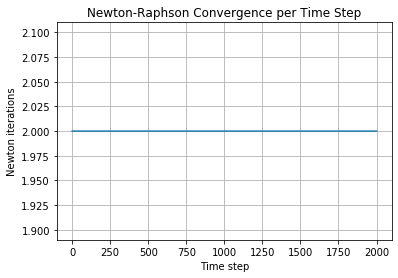

Average iterations: 2.0
Max iterations: 2
Min iterations: 2


In [15]:
#Newton-Raphson convergence analysis
#plotting the newton raphson fromm my previous function
plt.figure()
plt.plot(iters_list)
plt.xlabel("Time step")
plt.ylabel("Newton iterations")
plt.title("Newton-Raphson Convergence per Time Step")
plt.grid()
plt.show()
print("Average iterations:", np.mean(iters_list))
print("Max iterations:", np.max(iters_list))
print("Min iterations:", np.min(iters_list))

Newton Raphson's 2 step conversion shows that because the system is linear the implicit method is much more efficient and easier to use to solve this equation.

# Section 6: Performance Analysis

In [16]:
#Computational cost analysis seeitng the number of steps
#Performance analysis:
N_steps = len(t_values)
euler_cost = N_steps
be_cost = sum(iters_list)
avg_iters = np.mean(iters_list)
print("Euler Forward cost (function evaluations):", euler_cost)
print("Backward Euler cost (function evaluations):", be_cost)
print("Avg Newton iterations per step:", avg_iters)

Euler Forward cost (function evaluations): 2002
Backward Euler cost (function evaluations): 4002
Avg Newton iterations per step: 2.0


#Table comparing Euler's Forward vs. Backward
#Discussion of accuracy-efficiency tradeoff

Euler's forward implementation uses one value at a time to approximate the next, thus meaning it will use approximately the same about of functions as steps. However, Backward Euler uses 2 iterations per step on average so therefore it will have approximately double the computation cost while improving the accuracy. On the other hand Newton Raphson's iterations are much more computational efficient while maintaining accuracy because of the linearity of the function making it easy to solve with only 2 iterations. 

#Practical recommendations
For stiff equations, backwards euler is much more efficient and accurate than forward euler. While costing more time computationally it is more accurate and doesn't need such small steps to reach stability. Additionally, it won't need an extremely small step size as forward euler when it comes to stiff equations and has a wider stability range when it comes to the h step values. When Newton Raphson is implemented into the backwards euler, the process becomes more efficient, being able to converge in a few simple steps especially if the equation is linear. 

# Section 7: Conclusion

Summary of key findings

When working with stiff equations, forward euler implementations methods seldom work due to their inability to converge in an effective step requirement. Forward Euler methods require an extremely small h size to work with in order to converge for stiff equations. The Backward Euler method is much more accurate and precise when it comes to working with stiff equations. The backward euler can converge in bigger step sizes and it won't require as many steps to converge. The backward euler has a wider stability size region than the forward euler. Especially when paired with Newton Raphson iterations because with linear systems it proves to be extremely efficient in converging the equation due to it using tangent lines to approximate the function and since the tangent line in a linear equation is the equation itself Newton Raphson can just straight to the solution. 


When to use implicit vs. explicit methods

Explicit methods are useful for non-stiff equations. RK4 and Euler's forward are perfect explicit methods that will work for non-stiff equations especially when moderate step sizes work. However, in stiff systems euler's backward (especially with Newton Raphson's) are better because they allow larger time steps while maintaining stability.

Challenges encountered and lessons learned

Some challenges I encountered was the derivation between the functions and the way the backward eulers function worked and how to code it. I struggled with that intitally but it was really cool seeing how it worked and how it was able to reach stability efficiently. 